## Importation des Packages

In [1]:
using Pkg

cd(@__DIR__)
Pkg.activate("../")
using Dates, SonifSismo
using WAV
using CairoMakie
using DSP
using Statistics
using DelimitedFiles
using WAV

  Activating project at `c:\Users\ameli\Desktop\Stage\sonifSismo.jl`


In [2]:
dossier = "C:\\Users\\ameli\\Desktop\\Stage\\Résultats\\Rapport"

"C:\\Users\\ameli\\Desktop\\Stage\\Résultats\\Rapport"

## Lecture des fichiers

In [3]:
data = readdlm("C:\\Users\\ameli\\Desktop\\Stage\\sonifSismo.jl\\Mars\\withoutRegolith\\out0213.txt")

temps = data[:, 1]
U = data[:, 2]
N = data[:, 3]
E = data[:, 4]

println("C'est importé 🐧")


C'est importé 🐧


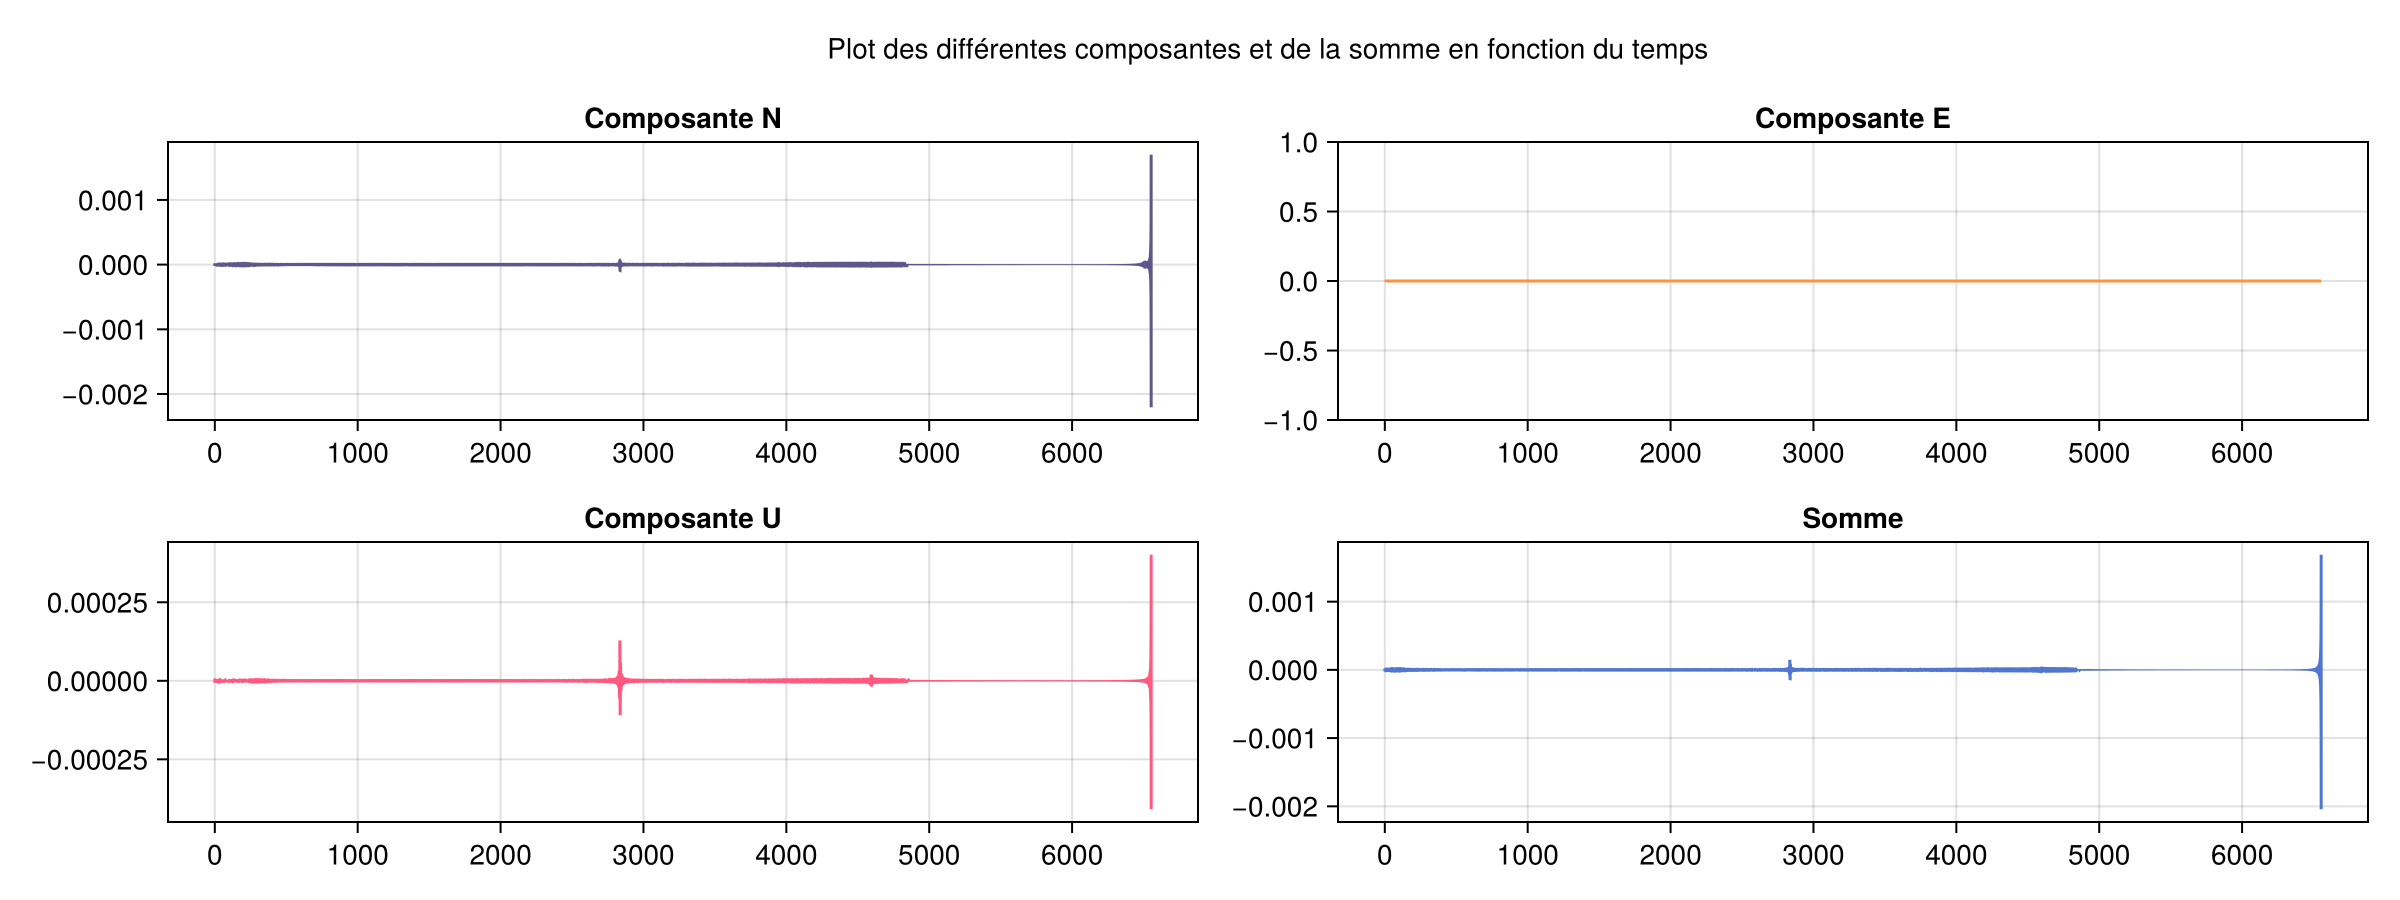

In [5]:
using CairoMakie


fig= Figure(size=(1200, 450))

Label(fig[0, 1:2], "Plot des différentes composantes et de la somme en fonction du temps")


ax1 = Axis(fig[1, 1], title="Composante N")
lines!(ax1,  temps, N, color="#5F568C")

ax2 = Axis(fig[1, 2], title="Composante E")
lines!(ax2, temps, E, color="#FE943B")

ax3 = Axis(fig[2, 1], title="Composante U")
lines!(ax3, temps, U, color="#FF5980")

ax4 = Axis(fig[2, 2], title="Somme")
lines!(ax4, temps,  U .+ N .+ E, color="#5176CF")

fig

## Sonification

In [6]:
include("C:/Users/ameli/Desktop/Stage/sonifSismo.jl/examples/sonify_one_trace.jl")

delta = temps[2] - temps[1]

trace_U = Trace(temps[1], delta, U)
trace_E = Trace(temps[1], delta, E)
trace_N = Trace(temps[1], delta, N)


sonifyU = sonify_trace(
    trace_U;
    acceleration=1000,
    #octave=1,
    #harmonics=(0.3, 0.2),
    #gain=2,
    saturation=:soft,
    level=1
)

sonifyN = sonify_trace(
    trace_N;
    acceleration=1000,
    #octave=1,
    #harmonics=(0.3, 0.2),
    #gain=2,
    saturation=:soft,
    level=1
)

sonifyE = sonify_trace(
    trace_E;
    acceleration=1000,
    #octave=1,
    #harmonics=(0.3, 0.2),
    #gain=2,
    saturation=:soft,
    level=1
)

somme = sonifyU[1] .+ sonifyE[1] .+ sonifyN[1]

289014-element Vector{Float64}:
  1.2461763481120038e-6
  4.698213302612479e-6
 -0.00024490075768621985
 -0.00043141028576486627
 -0.0005515091851899618
 -0.0003409883616982232
  0.0002746870493042948
  0.0008335997813042621
  0.0010191705621069428
  0.0010320778490064072
  6.0957628447739804e-5
 -0.0011272929026030702
 -0.0015282965189995761
  ⋮
  0.018040224573563298
  0.07417806241905486
  0.11851991975812116
  0.06938715600564908
  0.013037322583025564
 -0.03282882558320729
 -0.06557086462608974
 -0.05899050172877266
 -0.02311750369057504
 -0.003742135075152018
 -0.0007807788302518542
  1.2461763481120038e-6

In [7]:
const AUDIO_OUTPUT = joinpath(dossier)
mkpath(AUDIO_OUTPUT)

save(joinpath(AUDIO_OUTPUT, "Figure.png"), fig)

wavwrite(Float32.(sonifyU[1]), joinpath(AUDIO_OUTPUT, "Soni_U.wav"))
wavwrite(Float32.(sonifyE[1]), joinpath(AUDIO_OUTPUT, "Soni_E.wav"))
wavwrite(Float32.(sonifyN[1]), joinpath(AUDIO_OUTPUT, "Soni_N.wav"))
wavwrite(Float32.(sonifyU[1] .+ sonifyE[1] .+ sonifyN[1]), joinpath(AUDIO_OUTPUT, "Soni_somme.wav"))

## Convolution

In [147]:
musique, sr_musique = wavread("C:\\Users\\ameli\\Desktop\\Stage\\Stay.wav") #Mettre le lien de sa musique
signal = musique[1:1000000]

println(sr_musique) #Fréquence d'échantillonage

44100.0


In [163]:
include("C:/Users/ameli/Desktop/Stage/sonifSismo.jl/examples/sonify_one_trace.jl")

delta = temps[2] - temps[1]

trace_U = Trace(temps[1], delta, U)
trace_E = Trace(temps[1], delta, E)
trace_N = Trace(temps[1], delta, N)


sonifyU = sonify_trace(
    trace_U;
    acceleration=3000,
    #octave=1,
    harmonics=(0.3, 0.2),
    #gain=2,
    saturation=:soft,
    level=0.2
)

sonifyN = sonify_trace(
    trace_N;
    acceleration=3000,
    #octave=1,
    harmonics=(0.3, 0.2),
    #gain=2,
    saturation=:soft,
    level=0.2
)

sonifyE = sonify_trace(
    trace_E;
    acceleration=3000,
    #octave=1,
    harmonics=(0.3, 0.2),
    #gain=2,
    saturation=:soft,
    level=0.2
)

somme = sonifyU[1] .+ sonifyE[1] .+ sonifyN[1]


96338-element Vector{Float64}:
 -5.3783999522194114e-5
 -8.305153058317446e-5
 -3.3487872043261644e-5
  9.404628849604176e-6
 -0.00017012023377024855
 -1.4976957720558604e-5
  0.00011816090189499767
 -0.00018212237130233407
 -5.972725950858844e-5
  7.145593823233957e-5
 -0.0002368756985407595
  1.3474401335239984e-5
  0.0001800855631062149
  ⋮
 -0.007286078600397641
 -0.00803436503784535
  0.01374945738801503
 -0.006484363258367882
 -0.0057250228313197515
  0.012109070911075543
 -0.005133551212962162
 -0.003730561374387353
  0.008700196837239167
 -0.0027384316449344187
 -0.0016204347912660711
 -5.3783999522194114e-5

In [164]:
convolutionU = conv(sonifyU[1], signal) #Convolution
convolutionN = conv(sonifyN[1], signal) 
convolutionE = conv(sonifyE[1], signal) 
convolution_somme = conv(somme, signal)

const AUDIO_OUTPUT = joinpath(dossier)
mkpath(AUDIO_OUTPUT)

wavwrite(Float32.(convolutionU), joinpath(AUDIO_OUTPUT, "ConvolutionU.wav"), Fs=sr_musique)
wavwrite(Float32.(convolutionN), joinpath(AUDIO_OUTPUT, "ConvolutionN.wav"), Fs=sr_musique)
wavwrite(Float32.(convolutionE), joinpath(AUDIO_OUTPUT, "ConvolutionE.wav"), Fs=sr_musique)
wavwrite(Float32.(convolution_somme), joinpath(AUDIO_OUTPUT, "Convolution_somme.wav"), Fs=sr_musique)

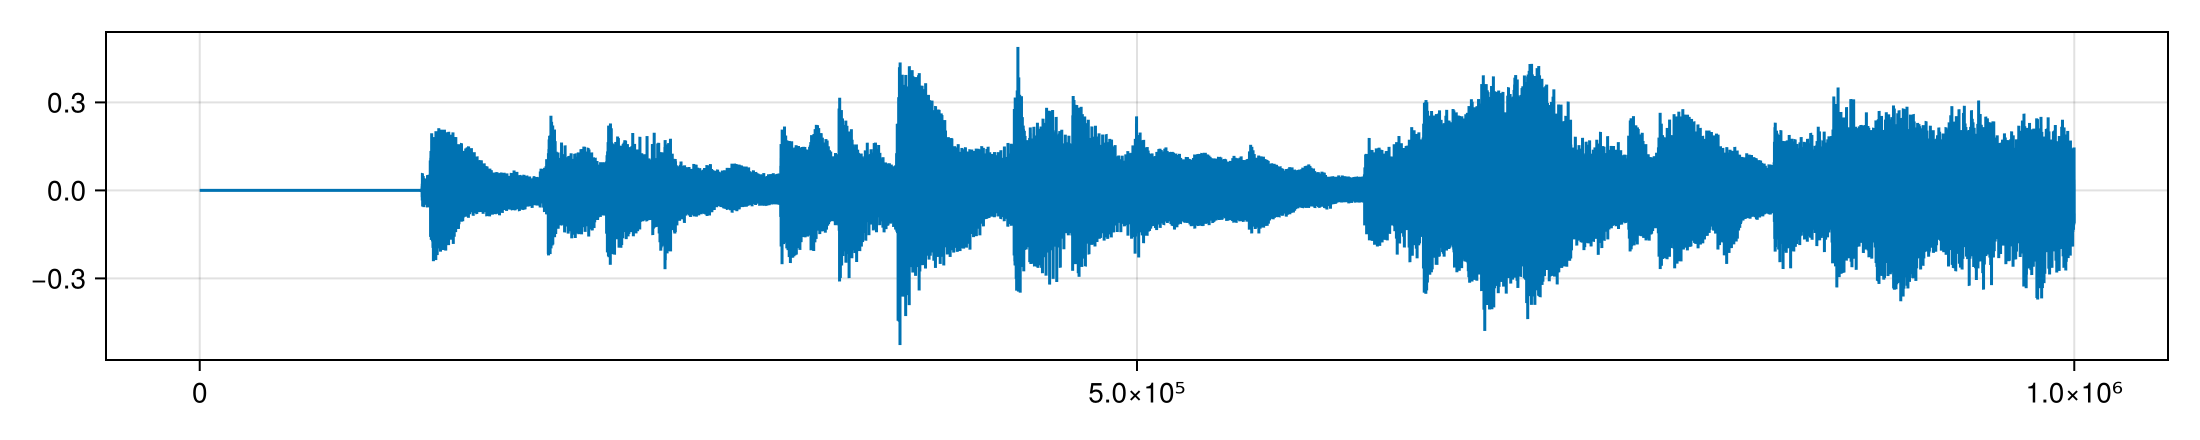

In [162]:
#Plot de la musique

fig_musique=Figure(size=(1100, 220))
ax=Axis(fig_musique[1,1])
lines!(signal)
fig_musique

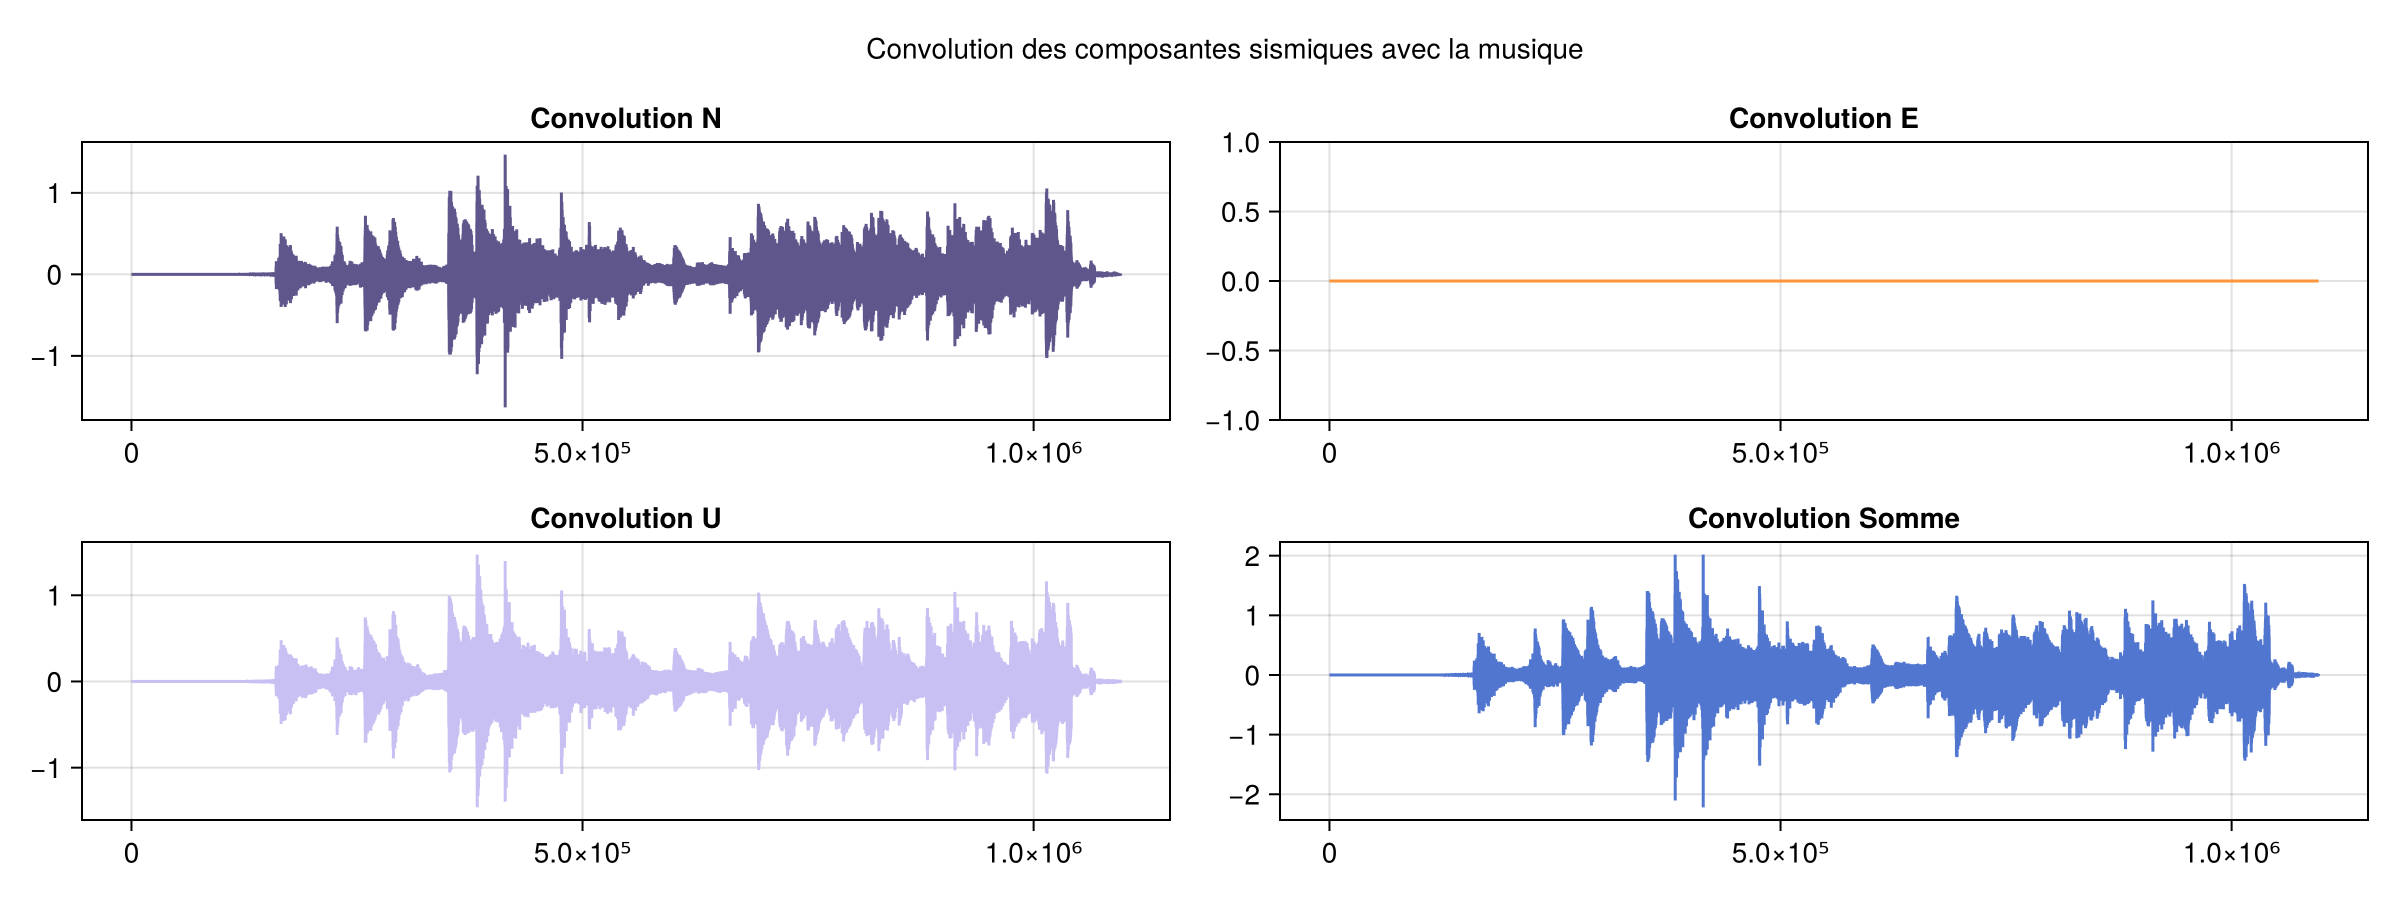

In [151]:


fig_conv = Figure(size=(1200, 450))

Label(fig_conv[0, 1:2], "Convolution des composantes sismiques avec la musique")


ax1 = Axis(fig_conv[1, 1], title="Convolution N")
lines!(ax1,  convolutionN, color="#5F568C")

ax2 = Axis(fig_conv[1, 2], title="Convolution E")
lines!(ax2, convolutionE, color="#FE943B")

ax3 = Axis(fig_conv[2, 1], title="Convolution U")
lines!(ax3, convolutionU, color="#C8BFF2")

ax4 = Axis(fig_conv[2, 2], title="Convolution Somme")
lines!(ax4, convolution_somme, color="#5176CF")

fig_conv

In [152]:
const AUDIO_OUTPUT = joinpath(dossier)
mkpath(AUDIO_OUTPUT)

save(joinpath(AUDIO_OUTPUT, "Convolution.png"), fig_conv)
save(joinpath(AUDIO_OUTPUT, "Musique.png"), fig_musique)


## Comparaison avec / sans régolithe

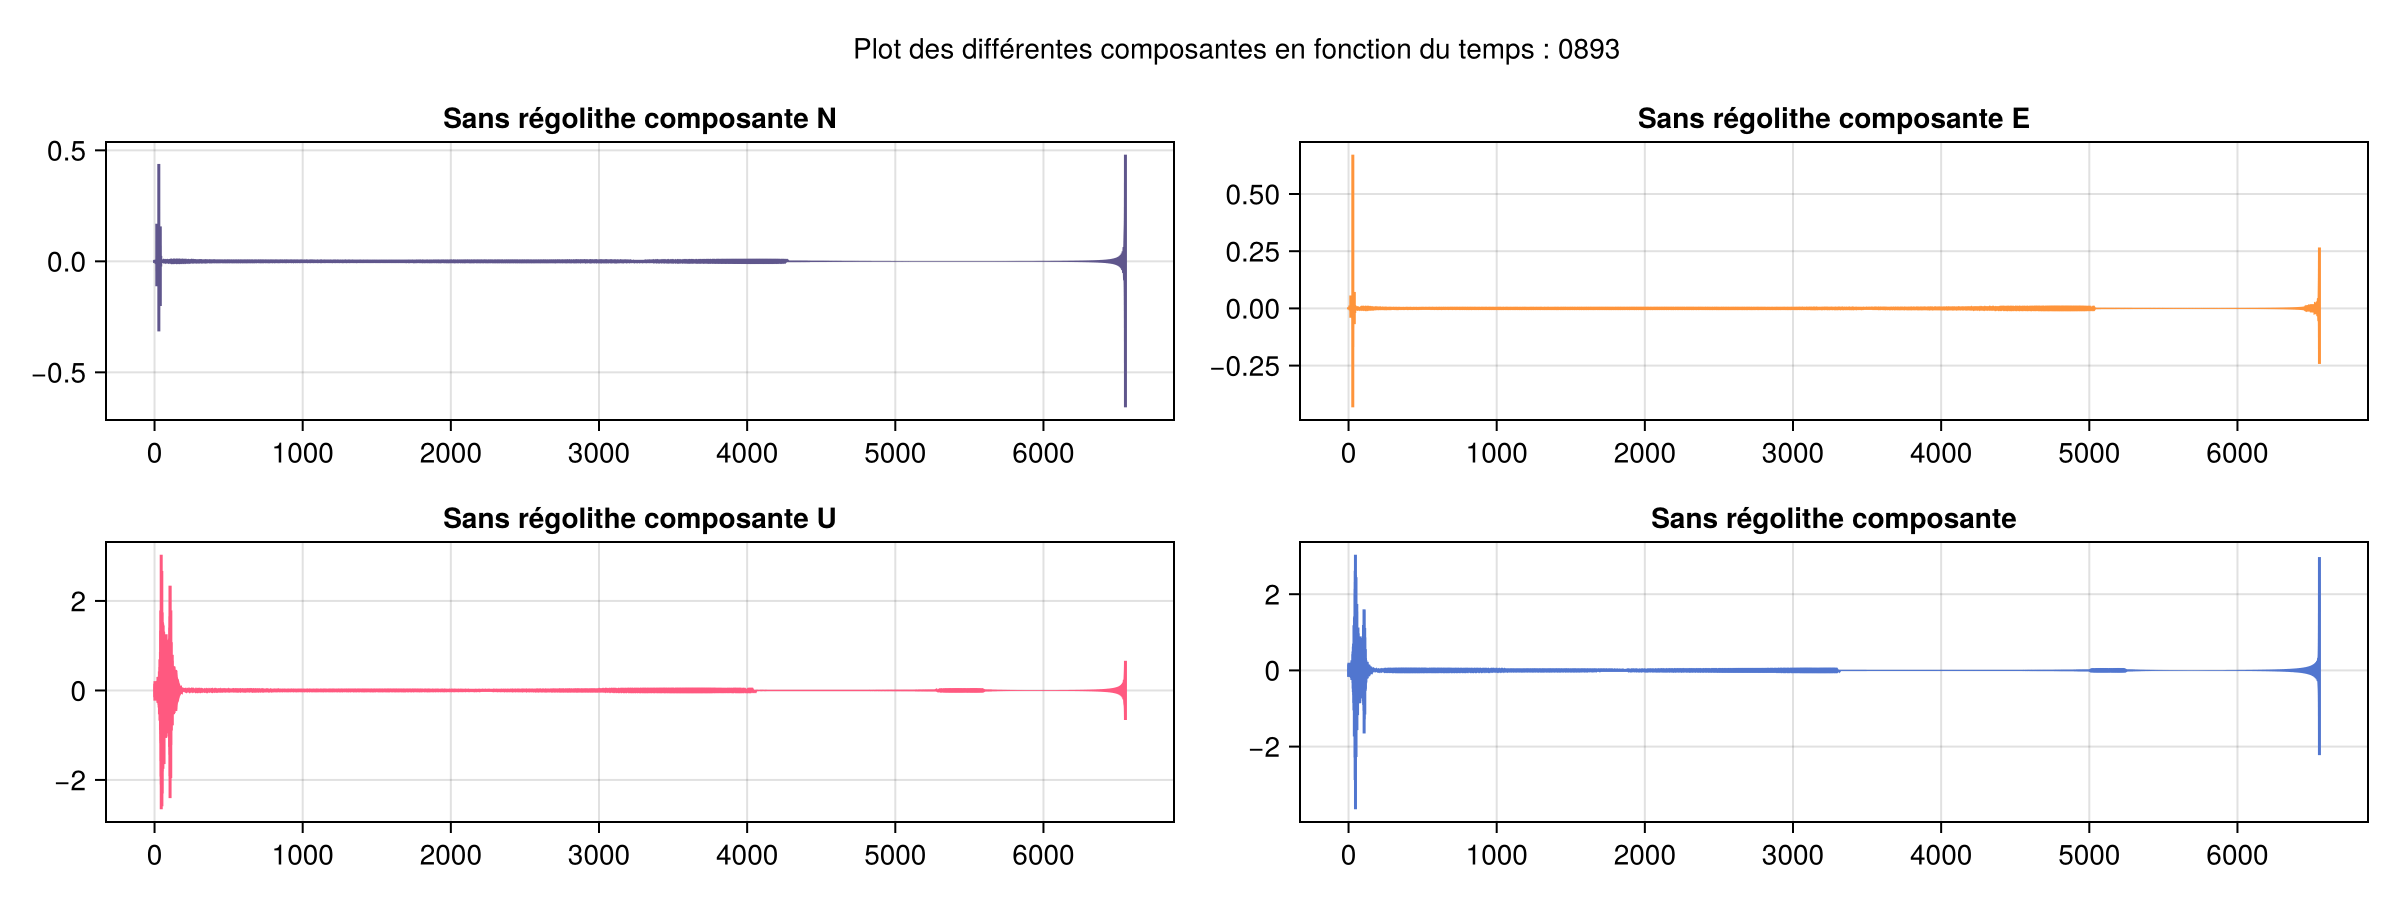

In [4]:

avec = readdlm("C:\\Users\\ameli\\Desktop\\Stage\\sonifSismo.jl\\Mars\\withRegolith\\out0893.txt")
sans = readdlm("C:\\Users\\ameli\\Desktop\\Stage\\sonifSismo.jl\\Mars\\withoutRegolith\\out0893.txt")

temps_a = avec[:, 1]
U_a = avec[:, 2]
N_a = avec[:, 3]
E_a = avec[:, 4]

temps_s = sans[:, 1]
U_s = sans[:, 2]
N_s = sans[:, 3]
E_s = sans[:, 4]

fig_comp= Figure(size=(1200, 450))

Label(fig_comp[0, 1:2], "Plot des différentes composantes en fonction du temps : 0893")

ax1 = Axis(fig_comp[1, 1], title="Sans régolithe composante N")
lines!(ax1,  temps, N_s, color="#5F568C")

ax2 = Axis(fig_comp[1, 2], title="Sans régolithe composante E")
lines!(ax2, temps, U_s, color="#FE943B")

ax3 = Axis(fig_comp[2, 1], title="Sans régolithe composante U")
lines!(ax3, temps, N_a, color="#FF5980")

ax4 = Axis(fig_comp[2, 2], title="Sans régolithe composante")
lines!(ax4, temps,  U_a, color="#5176CF")

const AUDIO_OUTPUT = joinpath("C:\\Users\\ameli\\Desktop\\Stage\\Résultats\\17Juin\\Comparaison")
mkpath(AUDIO_OUTPUT)

save(joinpath(AUDIO_OUTPUT, "Comparaison 0893.png"), fig_comp)

fig_comp


## Somme de tous les fichiers

In [112]:
#=
for i in range(0,900):
    => lire le fichier
    => séparer les colonnes
    => sonifier
    => additionner
=#

dossier = "C:\\Users\\ameli\\Desktop\\Stage\\Résultats\\18Juin\\test6"

include("C:/Users/ameli/Desktop/Stage/sonifSismo.jl/examples/sonify_one_trace.jl")

dossier2 = "C:\\Users\\ameli\\Desktop\\Stage\\sonifSismo.jl\\Mars\\withRegolith"
        
somme = nothing

for i in 1:900
    numero = lpad(i, 4, '0')  
    chemin = joinpath(dossier2, "out$(numero).txt") #permet de faire une boucle sur les fichiers pour tous les lires
    
    data = readdlm(chemin)
    
    temps = data[:,1]
    U = data[:,2]
    
    if any(isnan, U) #cette commande permet d'ignorer les fichiers avec NaN
        continue
    else
        delta = temps[2] - temps[1]
        trace_U = Trace(temps[1], delta, U) #création de la Trace

        sonifyU = sonify_trace(trace_U; acceleration=1000, saturation=:soft, level=0.01) #sonification

        if somme === nothing
            somme = sonifyU[1]
        else
            somme = somme .+ sonifyU[1] #créer la somme finale
        end
    end
end

In [113]:
musique, sr_musique = wavread("C:\\Users\\ameli\\Desktop\\Stage\\Grenade.wav") #Mettre le lien de sa musique
signal = musique[1550000:3100000]

println(sr_musique) #Fréquence d'échantillonage

44100.0


In [96]:
wavplay(signal, sr_musique)

In [114]:
convolution_full = conv(somme, signal)

if maximum(abs.(convolution_full)) > 1
    convolution_full = convolution_full ./ maximum(abs.(convolution_full))
end

const AUDIO_OUTPUT = joinpath(dossier)
mkpath(AUDIO_OUTPUT)

wavwrite(Float32.(convolution_full), joinpath(AUDIO_OUTPUT, "Convolution_withRegolith.wav"), Fs=sr_musique)

### Plot des courbes

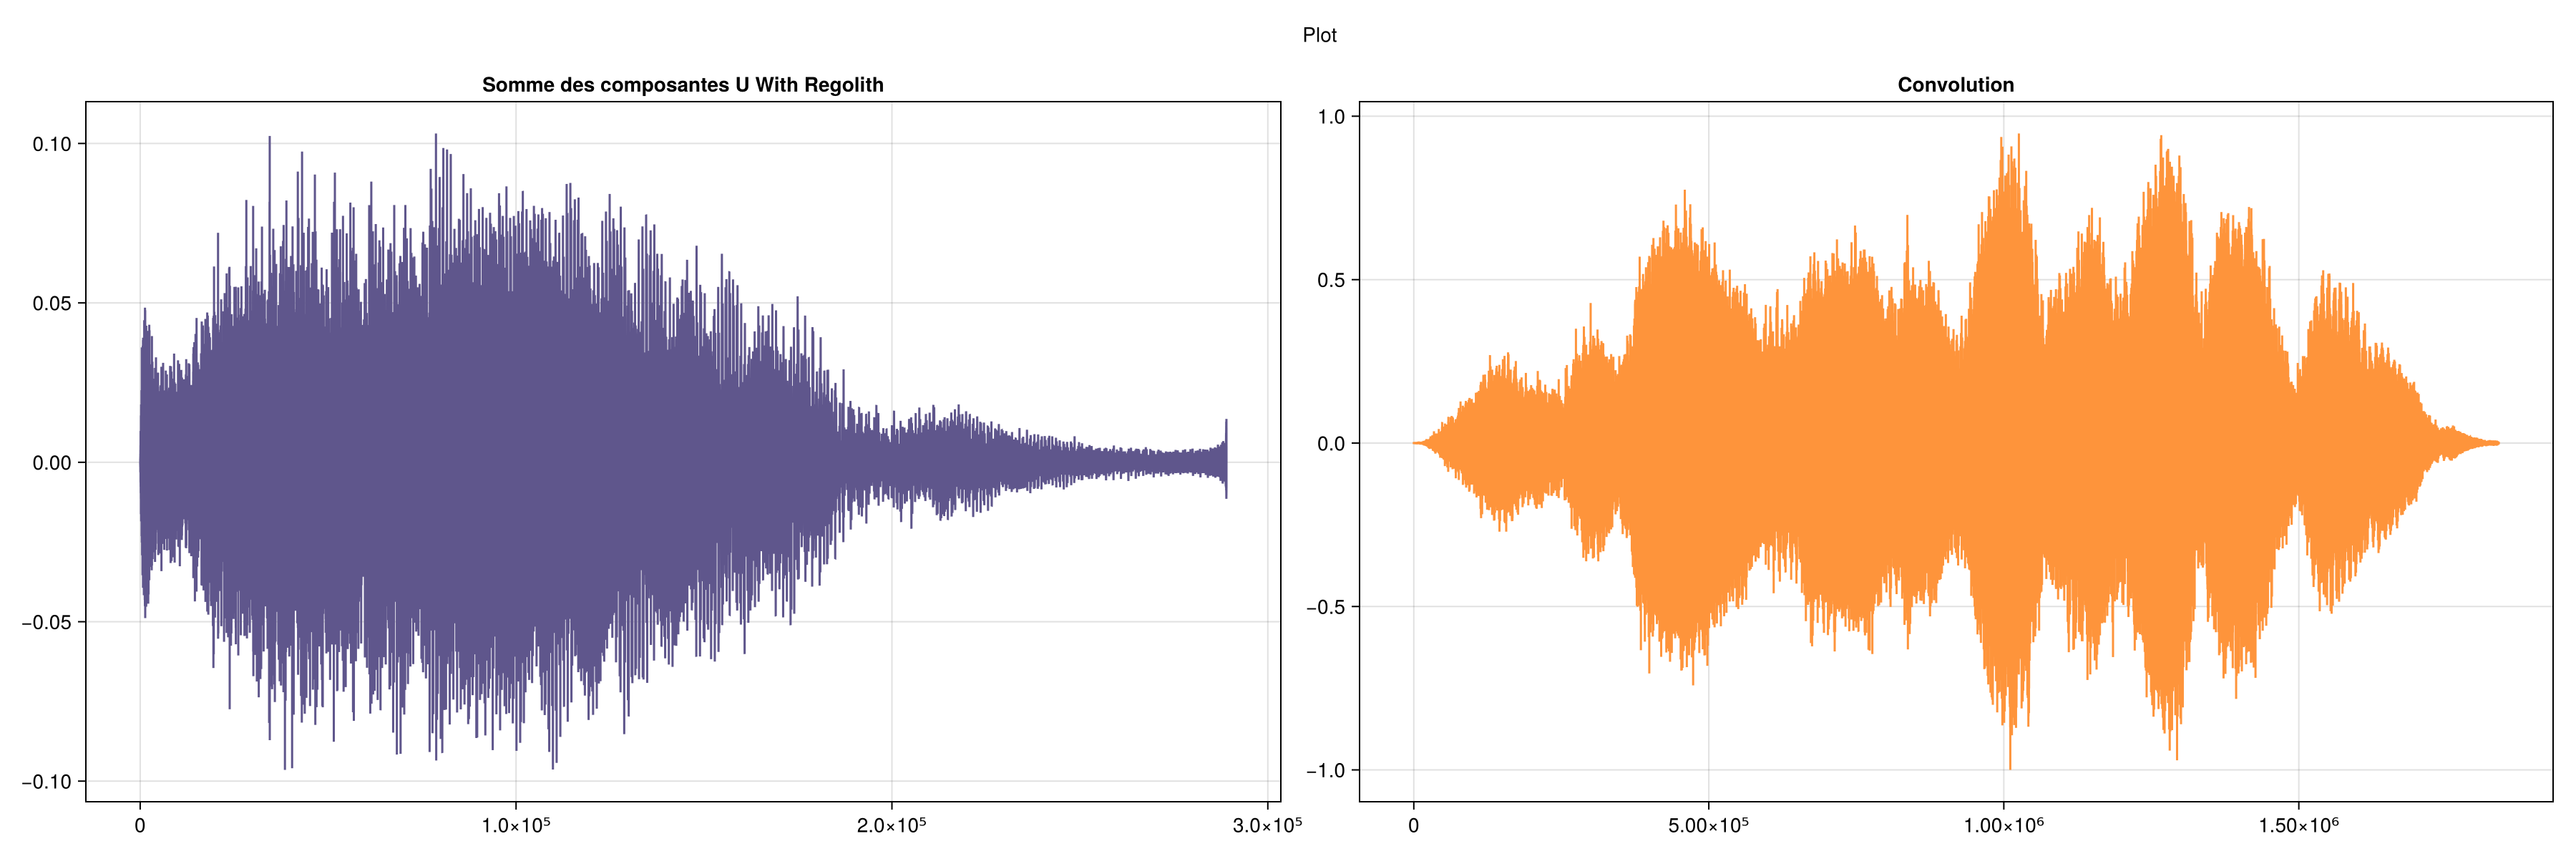

In [115]:
fig_full = Figure(size=(1800, 600))

Label(fig_full[0, 1:2], "Plot")

ax1 = Axis(fig_full[1, 1], title="Somme des composantes U With Regolith")
lines!(ax1, somme, color="#5F568C")

ax2 = Axis(fig_full[1, 2], title="Convolution")
lines!(ax2, convolution_full, color="#FE943B")

colsize!(fig_full.layout, 1, Relative(0.5))
colsize!(fig_full.layout, 2, Relative(0.5))

fig_full

In [116]:
const AUDIO_OUTPUT = joinpath(dossier)
mkpath(AUDIO_OUTPUT)

save(joinpath(AUDIO_OUTPUT, "Figure_full1.png"), fig_full)